In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
pd.set_option('display.max_columns', None)
pd.options.display.float_format = '{:.2f}'.format

In [2]:
df = pd.read_csv(r'C:\\Users\\rashid\\Desktop\\customer_churn_prediction\\data\\processed\\cleaned_data.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 📊 Data Dictionary (Məlumat Sütunları)

Layihədə istifadə olunan datada 7043 müştəriyə aid 21 sütun mövcuddur. Sütunların geniş təsviri aşağıdakı kəbdir:

| Sütun Adı | Data Tipi | Təsviri (Mənası) |
| :--- | :---: | :--- |
| **customerID** | str | Müştərinin unikal identifikasiya nömrəsi (ID) |
| **gender** | str | Müştərinin cinsi (Male/Female) |
| **SeniorCitizen** | int64 | Müştərinin təqaüdçü/yaşlı olub-olmaması (1: Bəli, 0: Xeyr) |
| **Partner** | str | Müştərinin partnyorunun olub-olmaması (Yes/No) |
| **Dependents** | str | Müştərinin himayəsində şəxslərin (uşaq, valideyn və s.) olub-olmaması (Yes/No) |
| **tenure** | int64 | Müştərinin şirkətdə qaldığı ayların sayı (Müştərilik müddəti) |
| **PhoneService** | str | Telefon xidmətinin aktiv olub-olmaması (Yes/No) |
| **MultipleLines** | str | Birdən çox telefon xəttinin olub-olmaması (Yes/No/No phone service) |
| **InternetService** | str | İnternet xidmət provayderinin növü (DSL, Fiber optic, No) |
| **OnlineSecurity** | str | Onlayn təhlükəsizlik xidmətinin olub-olmaması (Yes/No/No internet service) |
| **OnlineBackup** | str | Onlayn ehtiyat nüsxələmə (backup) xidmətinin olub-olmaması (Yes/No/No internet service) |
| **DeviceProtection** | str | Cihazın qorunması (sığortası) xidmətinin olub-olmaması (Yes/No/No internet service) |
| **TechSupport** | str | Texniki dəstək xidmətinin olub-olmaması (Yes/No/No internet service) |
| **StreamingTV** | str | TV yayımı xidmətinin olub-olmaması (Yes/No/No internet service) |
| **StreamingMovies** | str | Film yayımı xidmətinin olub-olmaması (Yes/No/No internet service) |
| **Contract** | str | Müqavilənin növü (Month-to-month, One year, Two year) |
| **PaperlessBilling** | str | Elektron faktura (kağızsız) sisteminin aktiv olub-olmaması (Yes/No) |
| **PaymentMethod** | str | Ödəniş üsulu (Electronic check, Mailed check, Bank transfer, Credit card) |
| **MonthlyCharges** | float64 | Müştərinin hər ay ödədiyi məbləğ |
| **TotalCharges** | str | Müştərinin ümumi ödədiyi məbləğ *(Qeyd: Bu sütun str tipindədir, float-a çevrilməlidir)* |
| **Churn** | str | **Hədəf Dəyişən (Target):** Müştərinin şirkəti tərk edib-etmədiyi (Yes/No) |

In [3]:
df.shape

(7043, 21)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7043.00,7043.00
mean,0.16,32.37,64.76,2279.73
std,0.37,24.56,30.09,2266.79
min,0.00,0.00,18.25,0.00
25%,0.00,9.00,35.50,398.55
50%,0.00,29.00,70.35,1394.55
75%,0.00,55.00,89.85,3786.60
max,1.00,72.00,118.75,8684.80


In [6]:
df.isnull().sum()   

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
mylist = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
for i in mylist:
    print(i, '\n')
    print(df[i].unique(), '\n')

gender 

<StringArray>
['Female', 'Male']
Length: 2, dtype: str 

SeniorCitizen 

[0 1] 

Partner 

<StringArray>
['Yes', 'No']
Length: 2, dtype: str 

Dependents 

<StringArray>
['No', 'Yes']
Length: 2, dtype: str 

PhoneService 

<StringArray>
['No', 'Yes']
Length: 2, dtype: str 

MultipleLines 

<StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str 

InternetService 

<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str 

OnlineSecurity 

<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str 

OnlineBackup 

<StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str 

DeviceProtection 

<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str 

TechSupport 

<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str 

StreamingTV 

<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str 

StreamingMovies 

<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: st

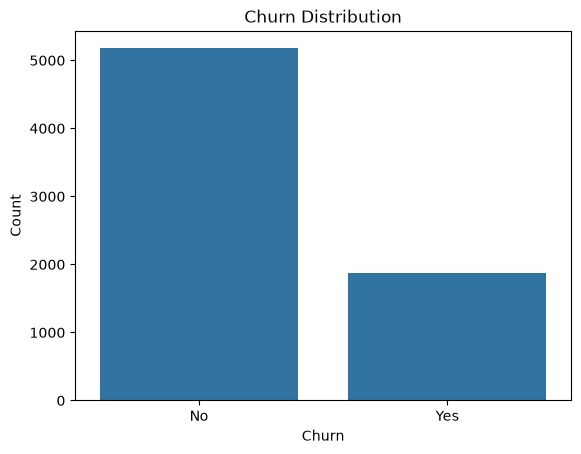

In [10]:
#chrun distribution
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()


In [11]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

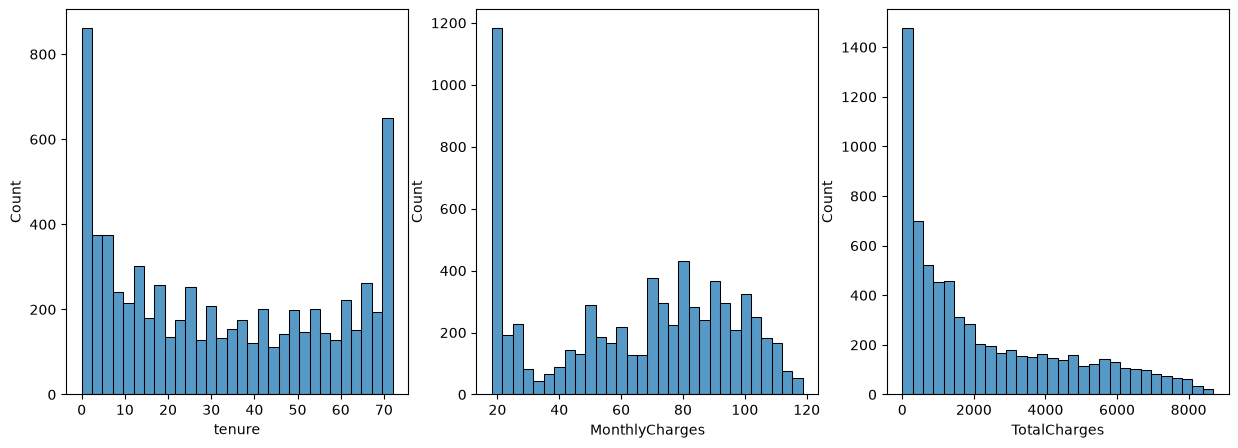

In [15]:
#tenure distribution; monthly charges distribution; total charges distribution in one output
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.histplot(x='tenure', data=df, bins=30, ax=axes[0])
sns.histplot(x='MonthlyCharges', data=df, bins=30, ax=axes[1])
sns.histplot(x='TotalCharges', data=df, bins=30, ax=axes[2])
plt.show()

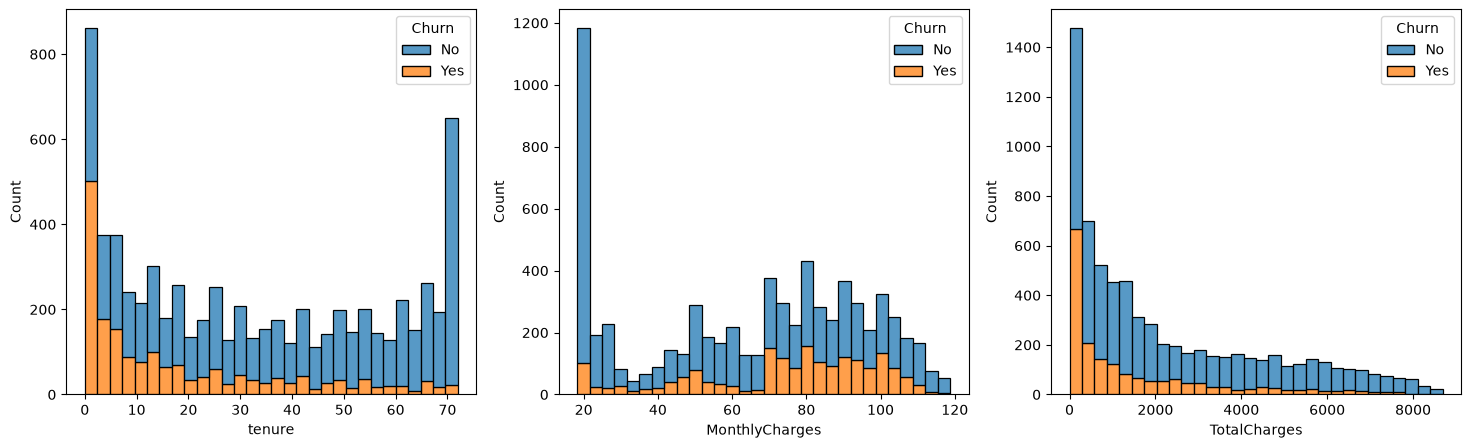

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(x='tenure', data=df, hue='Churn', multiple='stack', bins=30, ax=axes[0])
sns.histplot(x='MonthlyCharges', data=df, hue='Churn', multiple='stack', bins=30, ax=axes[1])
sns.histplot(x='TotalCharges', data=df, hue='Churn', multiple='stack', bins=30, ax=axes[2])

plt.show()

In [22]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

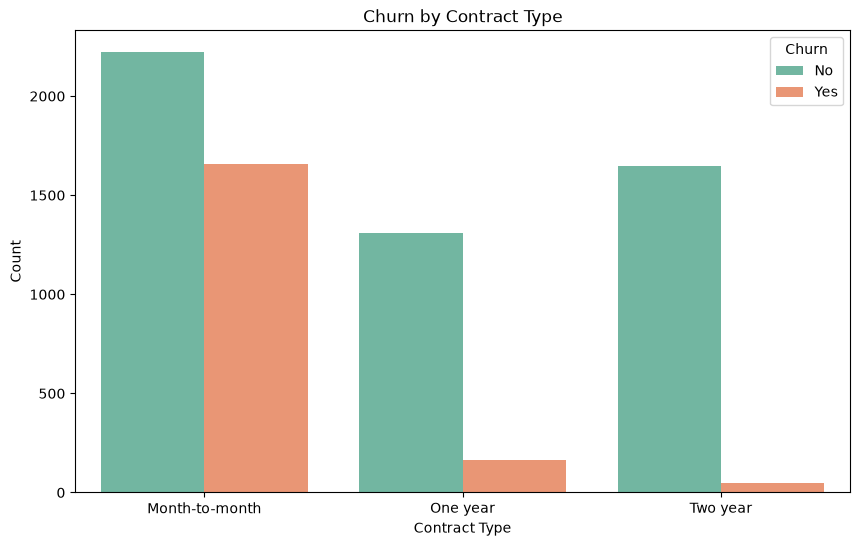

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(data = df, x = 'Contract', hue = 'Churn', palette = 'Set2')
plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.show()  
"""
Göründüyü kimi month-to-month müqavilələrdə müştəri itkisi daha yüksəkdir.
Müştərilər uzunmüddətli müqavilələrə üstünlük verirlər, çünki bu, onlara daha çox sabitlik və aşağı aylıq ödənişlər təklif edir.
Bu məlumatlar əsasında şirkət müştəriləri uzunmüddətli müqavilələrə cəlb etmək üçün xüsusi kampaniyalar və təşviqlər həyata keçirə bilər.


"""

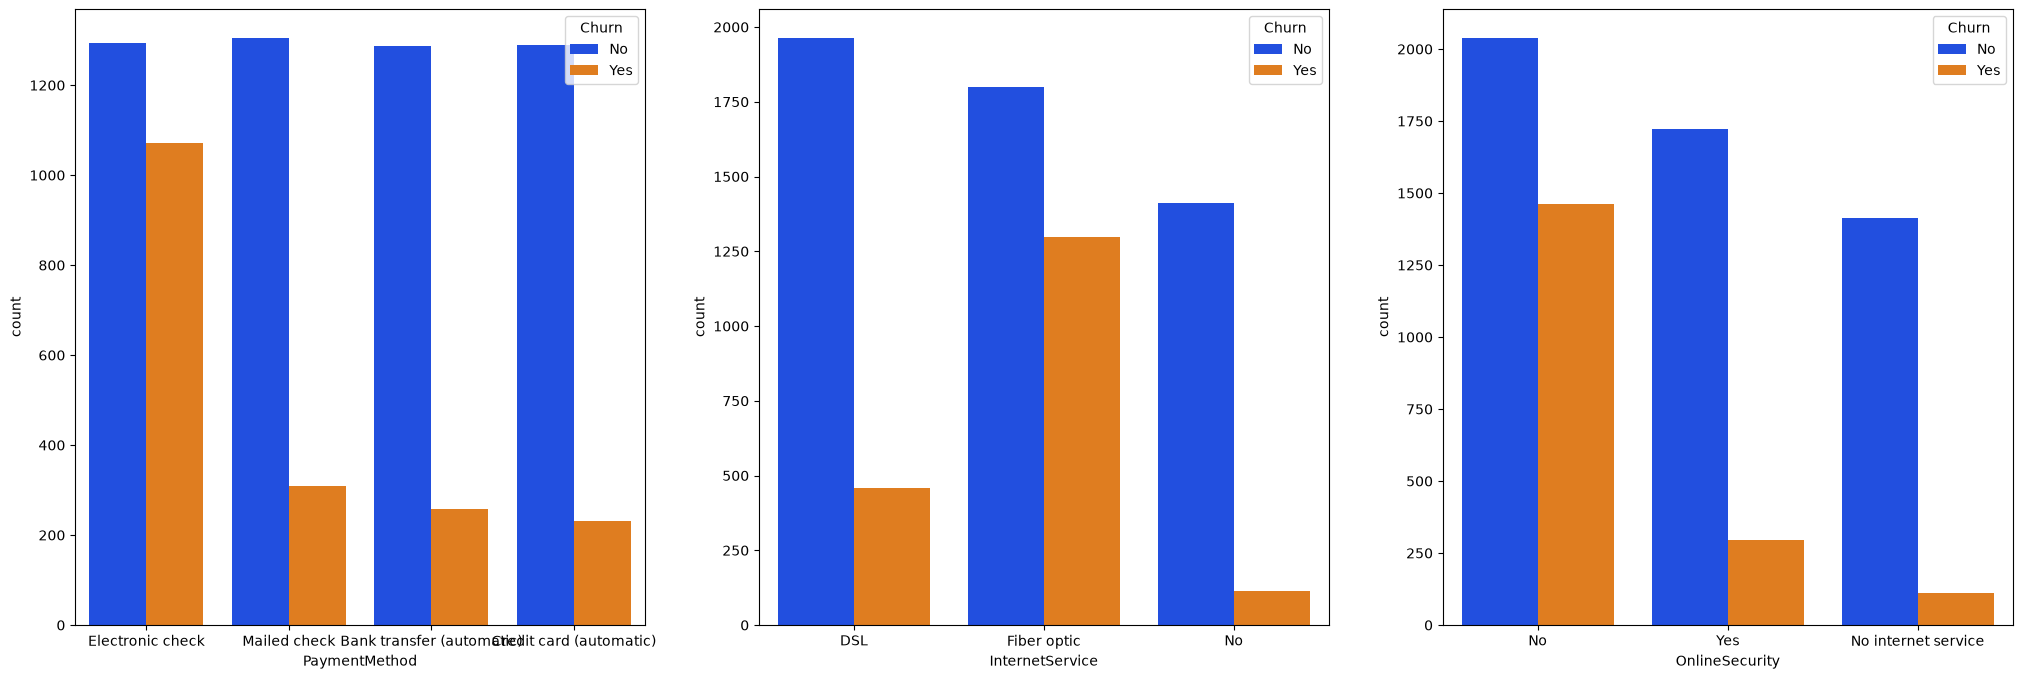

'\n1.Electronic check ödəniş üsulu ilə ödəniş edən müştərilər arasında müştəri itkisi daha yüksəkdir.\nBu, elektron çek ödəniş üsulunun daha az etibarlı və ya daha az rahat olduğunu göstərə bilər.\nŞirkət, elektron çek ödəniş üsulunu istifadə edən müştərilərə əlavə təşviqlər və ya üstünlüklər təqdim edərək müştəri itkisini azaltmağa çalışa bilər.\n\n2. Fiber optic internet xidmətindən istifadə edən müştərilər arasında müştəri itkisi daha yüksəkdir.\nBuna görəFiber optic internet xidmətinin daha yüksək qiymətə malik olması və ya xidmət keyfiyyətində problemlərin olması səbəb ola bilər.\nTəklif olaraq fiber optic kabellərinin keyfiyyətini artırmaq və ya müştərilərə daha sərfəli paketlər təqdim etmək müştəri itkisini azaltmağa kömək edə bilər.\nya da ki tech supoort bu tip customerlər üçün daha çox dəstək və xidmət təqdim etmək müştəri itkisini azaltmağa kömək edə bilər.\n\n3. OnlineSecurity xidmətindən istifadə etməyən müştərilər arasında müştəri itkisi daha yüksəkdir.\nBu, müştərilərin 

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(25, 8))

sns.countplot(data = df, x = 'PaymentMethod', hue = 'Churn', palette = 'bright', ax=axes[0])
sns.countplot(data = df, x = 'InternetService', hue = 'Churn', palette = 'bright', ax=axes[1])
sns.countplot(data = df, x = 'OnlineSecurity', hue = 'Churn', palette = 'bright', ax=axes[2])

plt.show()  
"""
1.Electronic check ödəniş üsulu ilə ödəniş edən müştərilər arasında müştəri itkisi daha yüksəkdir.
Bu, elektron çek ödəniş üsulunun daha az etibarlı və ya daha az rahat olduğunu göstərə bilər.
Şirkət, elektron çek ödəniş üsulunu istifadə edən müştərilərə əlavə təşviqlər və ya üstünlüklər təqdim edərək müştəri itkisini azaltmağa çalışa bilər.

2. Fiber optic internet xidmətindən istifadə edən müştərilər arasında müştəri itkisi daha yüksəkdir.
Buna görəFiber optic internet xidmətinin daha yüksək qiymətə malik olması və ya xidmət keyfiyyətində problemlərin olması səbəb ola bilər.
Təklif olaraq fiber optic kabellərinin keyfiyyətini artırmaq və ya müştərilərə daha sərfəli paketlər təqdim etmək müştəri itkisini azaltmağa kömək edə bilər.
ya da ki tech supoort bu tip customerlər üçün daha çox dəstək və xidmət təqdim etmək müştəri itkisini azaltmağa kömək edə bilər.

3. OnlineSecurity xidmətindən istifadə etməyən müştərilər arasında müştəri itkisi daha yüksəkdir.
Bu, müştərilərin onlayn təhlükəsizlik xidmətlərinə daha çox ehtiyac buna görə də Online Securtiy xidmətində bəzi kompaniyalar təklif edərək müştəriləri cəlb edə bilər.
"""

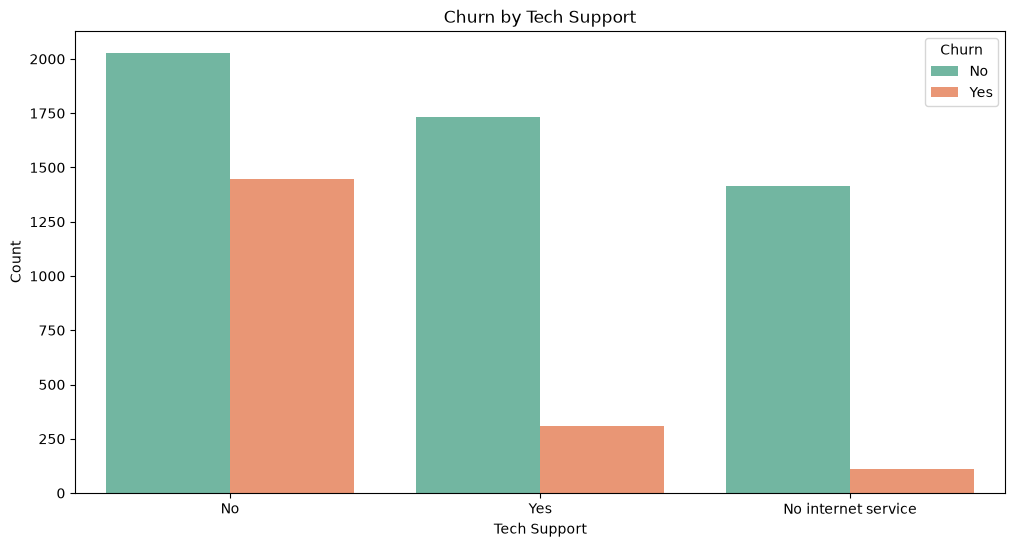

In [28]:
plt.figure(figsize=(12,6))
sns.countplot(data = df, x = 'TechSupport', hue = 'Churn', palette = 'Set2')
plt.title('Churn by Tech Support')
plt.xlabel('Tech Support')
plt.ylabel('Count')
plt.show()

In [32]:
df_temp = df.copy()
df_temp['Churn'] = df_temp['Churn'].map({'Yes':1, 'No':0})

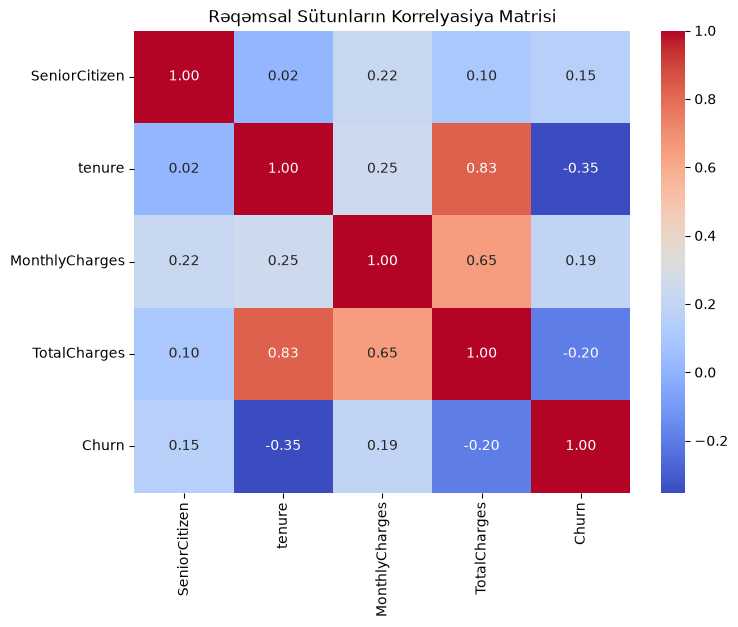

In [34]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_temp.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Rəqəmsal Sütunların Korrelyasiya Matrisi')
plt.show()